# Random Forest Regression

In the previous notebook, we built and tuned a Decision Tree Regressor.

Our tuned decision tree achieved a test R² of approximately 0.728.

However, a single decision tree can be sensitive to the particular training data. Small changes in the training data can sometimes produce a different tree structure and therefore different predictions.

Random Forest is an ensemble learning method that addresses this limitation by combining predictions from many decision trees.

In this notebook, we will:

1. Understand why a single decision tree can be unstable.
2. Understand the idea of ensemble learning.
3. Learn how Random Forest combines multiple decision trees.
4. Understand bootstrap sampling.
5. Understand random feature selection.
6. Build a small Random Forest conceptually.
7. Train a `RandomForestRegressor` using Scikit-learn.
8. Compare it with our tuned Decision Tree.
9. Tune the Random Forest using cross-validation.

## Why Use More Than One Decision Tree?

A decision tree learns its structure from the training data.

The training process determines:

- which feature is selected for a split,
- which threshold is selected,
- which samples reach each leaf,
- and therefore the prediction made by each leaf.

Because the tree depends on the training data, changing the data can change the resulting tree.

This means that a single decision tree can have relatively high variance.

Random Forest reduces this problem by training many different decision trees and combining their predictions.

## Ensemble Learning

An **ensemble** is a machine learning model that combines multiple individual models.

Instead of relying on one model:

$$
\text{Prediction} = \text{Model}_1(X)
$$

we can combine several models:

$$
\text{Prediction}
=
\text{combine}(
\text{Model}_1(X),
\text{Model}_2(X),
\dots,
\text{Model}_T(X)
)
$$

Random Forest is an ensemble of decision trees.

For regression, the predictions of the individual trees are averaged:

$$
\hat{y}
=
\frac{1}{T}
\sum_{t=1}^{T}
\hat{y}_t
$$

where:

- $T$ is the number of trees.
- $\hat{y}_t$ is the prediction made by tree $t$.
- $\hat{y}$ is the final Random Forest prediction.

The central idea is therefore:

> Instead of trusting one decision tree, combine the predictions of many trees.

## A Simple Random Forest Example

Suppose five decision trees make the following predictions for one house:

$$
2.0,\ 2.4,\ 2.2,\ 2.6,\ 2.3
$$

The Random Forest averages these predictions:

$$
\hat y =
\frac{2.0+2.4+2.2+2.6+2.3}{5}
=2.3
$$

Therefore, the final prediction of the forest is 2.3.

The individual trees may disagree, but averaging their predictions can produce a more stable prediction.

## Bootstrap Sampling

If we trained every decision tree on exactly the same training data, the trees would tend to learn very similar structures.

Random Forest avoids this by giving each tree a different training dataset.

It creates these datasets using **bootstrap sampling**.

Bootstrap sampling means repeatedly selecting samples from the original training data **with replacement**.

For example, suppose our training dataset contains only:

$$
[A,\ B,\ C,\ D,\ E]
$$

A bootstrap sample could be:

$$
[A,\ C,\ C,\ E,\ A]
$$

Notice that:

- `A` appears twice.
- `C` appears twice.
- `B` and `D` were not selected.
- The bootstrap sample still contains 5 observations.

Another tree might receive:

$$
[B,\ D,\ A,\ D,\ E]
$$

This gives the trees different training data, causing them to learn different structures.

In [33]:
import numpy as np

data = np.array(["A", "B", "C", "D", "E"])

bootstrap_sample = np.random.choice(
    data,
    size = len(data),
    replace=True
)

print("Original data:", data)
print("Bootstrap sample:", bootstrap_sample)

Original data: ['A' 'B' 'C' 'D' 'E']
Bootstrap sample: ['A' 'C' 'C' 'A' 'C']


## Bootstrap Samples in Random Forest

For our California Housing training data, we have 16,512 training observations.

Random Forest can create a bootstrap sample of approximately the same size for each tree by sampling the training observations with replacement.

For example:

$$
\text{Training data}
\rightarrow
\begin{cases}
\text{Bootstrap sample 1} \rightarrow \text{Tree 1}\\
\text{Bootstrap sample 2} \rightarrow \text{Tree 2}\\
\text{Bootstrap sample 3} \rightarrow \text{Tree 3}\\
\vdots\\
\text{Bootstrap sample T} \rightarrow \text{Tree T}
\end{cases}
$$

Because the samples are randomly generated, the trees receive different training data and can therefore learn different structures.

This is one of the sources of randomness in a Random Forest.

## Random Feature Selection

Our California Housing dataset has 8 features:

- `MedInc`
- `HouseAge`
- `AveRooms`
- `AveBedrms`
- `Population`
- `AveOccup`
- `Latitude`
- `Longitude`

If every tree could always consider all 8 features when making every split, the trees could still become quite similar, especially when some features are much more useful than others.

Random Forest introduces another source of randomness.

When a tree is deciding how to split a node, it considers only a randomly selected subset of the available features.

For example, instead of considering all 8 features, a particular split might consider:

$$
\{\text{MedInc},\text{AveRooms},\text{Latitude}\}
$$

Another split might consider:

$$
\{\text{HouseAge},\text{Population},\text{Longitude}\}
$$

The subset is selected randomly.

Therefore, different trees can be encouraged to learn different patterns from the data.

### A Small Example

Suppose a dataset contains four features:

$$
A,\ B,\ C,\ D
$$

At a particular split, different trees might receive different random subsets:

- Tree 1 → `A, C`
- Tree 2 → `B, D`
- Tree 3 → `A, B`

Each tree must choose its split from the features available to it.

This means that even if one feature is very strong, it may not always be available at every split.

This encourages the trees to become less correlated with one another.

## How Random Forest Works

A Random Forest combines two sources of randomness.

### 1. Bootstrap Sampling

Each tree receives a different bootstrap sample of the training data.

The samples are selected with replacement.

### 2. Random Feature Selection

When splitting a node, the tree considers only a randomly selected subset of the available features.

These two mechanisms create a collection of different decision trees.

Each tree makes its own prediction.

For regression, the Random Forest averages these predictions:

$$
\hat{y}
=
\frac{1}{T}
\sum_{t=1}^{T}\hat{y}_t
$$

Therefore, the overall process is:

$$
\text{Training Data}
\rightarrow
\text{Random Samples}
\rightarrow
\text{Different Trees}
\rightarrow
\text{Individual Predictions}
\rightarrow
\text{Average}
\rightarrow
\text{Final Prediction}
$$

## A Small Forest

Before using Scikit-learn's `RandomForestRegressor`, we will simulate the basic idea using a small dataset.

The purpose is not to reproduce the complete Random Forest algorithm ourselves.

Instead, we want to see the central mechanism:

$$
\text{Multiple Trees}
\rightarrow
\text{Multiple Predictions}
\rightarrow
\text{Average}
$$

In [34]:
import numpy as np

X_small = np.array([
    [1],
    [2],
    [3],
    [4],
    [5],
    [6],
    [7],
    [8]
])

y_small = np.array([
    2,
    4,
    5,
    8,
    9,
    12,
    13,
    16,
])

In [35]:
rng = np.random.default_rng(42)

indices_1 = rng.choice(len(X_small), size=len(X_small), replace=True)
indices_2 = rng.choice(len(X_small), size=len(X_small), replace=True)
indices_3 = rng.choice(len(X_small), size=len(X_small), replace=True)

X1 = X_small[indices_1]
y1 = y_small[indices_1]

X2 = X_small[indices_2]
y2 = y_small[indices_2]

X3 = X_small[indices_3]
y3 = y_small[indices_3]

print("Tree 1 indices:", indices_1)
print("Tree 2 indices:", indices_2)
print("Tree 3 indices:", indices_3)

Tree 1 indices: [0 6 5 3 3 6 0 5]
Tree 2 indices: [1 0 4 7 5 6 5 6]
Tree 3 indices: [4 1 6 3 4 2 1 7]


In [36]:
from sklearn.tree import DecisionTreeRegressor

tree_1 = DecisionTreeRegressor(
    max_depth=3,
    random_state=1
)

tree_2 = DecisionTreeRegressor(
    max_depth=3,
    random_state=2
)

tree_3 = DecisionTreeRegressor(
    max_depth=3,
    random_state=3
)

tree_1.fit(X1, y1)
tree_2.fit(X2, y2)
tree_3.fit(X3, y3)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",3
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_

In [37]:
sample = np.array([[5.5]])

pred1 = tree_1.predict(sample)[0]
pred2 = tree_2.predict(sample)[0]
pred3 = tree_3.predict(sample)[0]

print("Tree 1 prediction:", pred1)
print("Tree 2 prediction:", pred2)
print("Tree 3 prediction:", pred3)

Tree 1 prediction: 12.0
Tree 2 prediction: 9.0
Tree 3 prediction: 9.0


In [38]:
forest_prediction = np.mean([
    pred1,
    pred2,
    pred3
])

print("Random Forest prediction:", forest_prediction)

Random Forest prediction: 10.0


## What We Just Demonstrated

We created three decision trees using different bootstrap samples.

Because the trees received different training observations, they could learn different structures and produce different predictions.

We then averaged their predictions.

This is the central idea behind Random Forest regression.

A Random Forest does not necessarily make every individual tree better.

Instead, it combines many different trees so that the final prediction can be more stable than the prediction of a single tree.

The next step is to replace our manually constructed collection of trees with Scikit-learn's `RandomForestRegressor` and see whether this ensemble improves upon our tuned decision tree.

## Training Our First Random Forest

We now understand the basic idea behind a Random Forest:

1. Create different training samples using bootstrap sampling.
2. Train different decision trees.
3. Introduce randomness in feature selection.
4. Combine the predictions of the trees by averaging them.

We will now use Scikit-learn's `RandomForestRegressor`, which implements this process for us.

For this first experiment, we will use the original, unscaled features.

Decision trees and Random Forests do not require feature scaling because they make decisions using feature thresholds rather than distances or gradient-based optimization.

In [39]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)

In [40]:
df = housing.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [41]:
X = df.drop("MedHouseVal", axis = 1)
y = df["MedHouseVal"]

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (16512, 8)
X_test: (4128, 8)


In [43]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [44]:
forest.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [45]:
y_pred_forest = forest.predict(X_test)

In [46]:
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred_forest)
mse = mean_squared_error(y_test, y_pred_forest)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_forest)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.32773108008720936
MSE: 0.25602182673365537
RMSE: 0.5059859946022769
R²: 0.8046244867176197


## First Random Forest Results

Our first Random Forest contains 100 decision trees.

Without performing any hyperparameter tuning, it achieved:

- MAE: approximately 0.328
- MSE: approximately 0.256
- RMSE: approximately 0.506
- R²: approximately 0.805

The test R² is substantially higher than both our linear regression baseline and our tuned single decision tree.

This demonstrates the main benefit we wanted to investigate: combining many diverse decision trees can produce a more stable and accurate prediction than relying on a single tree.

The forest achieves this by training multiple trees using randomized samples and feature selection, then averaging their predictions for regression.

In [47]:
print("Number of trees:", len(forest.estimators_))

Number of trees: 100


In [48]:
print(forest.estimators_[0].get_depth)

<bound method BaseDecisionTree.get_depth of DecisionTreeRegressor(max_features=1.0, random_state=1608637542)>


In [49]:
depths = []

for tree in forest.estimators_:
    depths.append(tree.get_depth())

print("Minimum depth:", min(depths))
print("Maximum depth:", max(depths))
print("Average depth:", np.mean(depths))

Minimum depth: 29
Maximum depth: 38
Average depth: 33.37


In [50]:
y_train_pred_forest = forest.predict(X_train)

train_r2 = r2_score(y_train, y_train_pred_forest)
test_r2 = r2_score(y_test, y_pred_forest)

print("Training R²:", train_r2)
print("Test R²:", test_r2)

Training R²: 0.9735148362732539
Test R²: 0.8046244867176197


In [51]:
n_values = [10, 50, 100, 200, 300]

results = []

for n in n_values:
    model = RandomForestRegressor(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    results.append((n, train_r2, test_r2))

for n, train_r2, test_r2 in results:
    print(
        f"Trees: {n:3d} | "
        f"Training R²: {train_r2:.4f} | "
        f"Test R²: {test_r2:.4f}"
    )

Trees:  10 | Training R²: 0.9625 | Test R²: 0.7843
Trees:  50 | Training R²: 0.9723 | Test R²: 0.8040
Trees: 100 | Training R²: 0.9735 | Test R²: 0.8046
Trees: 200 | Training R²: 0.9742 | Test R²: 0.8059
Trees: 300 | Training R²: 0.9744 | Test R²: 0.8063


In [52]:
max_depth_values = [5, 10, 15, 20, None]

results_depth = []

for depth in max_depth_values:
    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    results_depth.append((depth, train_r2, test_r2))

for depth, train_r2, test_r2 in results_depth:
    print(
        f"Max depth: {str(depth):>4} | "
        f"Training R²: {train_r2:.4f} | "
        f"Test R²: {test_r2:.4f}"
    )

Max depth:    5 | Training R²: 0.6819 | Test R²: 0.6468
Max depth:   10 | Training R²: 0.8719 | Test R²: 0.7738
Max depth:   15 | Training R²: 0.9567 | Test R²: 0.8004
Max depth:   20 | Training R²: 0.9721 | Test R²: 0.8044
Max depth: None | Training R²: 0.9735 | Test R²: 0.8046


## Effect of Maximum Tree Depth

We investigated how limiting the depth of the individual trees affects the Random Forest.

At a maximum depth of 5, the model achieved a training R² of approximately 0.682 and a test R² of approximately 0.647. The relatively low training performance indicates that the trees were too restricted to capture the patterns in the data.

As the maximum depth increased, both training and test performance improved.

At a maximum depth of 20, the test R² reached approximately 0.804. Allowing unrestricted depth (`max_depth=None`) increased the test R² only slightly to approximately 0.805.

This shows that increasing tree depth initially helps the model capture more complex relationships, but the benefit eventually becomes very small.

The experiment also shows that the Random Forest behaves differently from a single decision tree. Although the individual trees can become very deep, averaging many trees helps the overall model generalize well.

In [56]:
min_leaf_values = [1, 2, 5, 10, 20, 50]

results_leaf = []

for leaf in min_leaf_values:
    model = RandomForestRegressor(
        n_estimators=100,
        min_samples_leaf=leaf,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    results_leaf.append((leaf, train_r2, test_r2))

for leaf, train_r2, test_r2 in results_leaf:
    print(
        f"Min samples leaf: {leaf:2d} | "
        f"Training R²: {train_r2:.4f} | "
        f"Test R²: {test_r2:.4f}"
    )

Min samples leaf:  1 | Training R²: 0.9735 | Test R²: 0.8046
Min samples leaf:  2 | Training R²: 0.9583 | Test R²: 0.8057
Min samples leaf:  5 | Training R²: 0.9119 | Test R²: 0.7990
Min samples leaf: 10 | Training R²: 0.8688 | Test R²: 0.7866
Min samples leaf: 20 | Training R²: 0.8280 | Test R²: 0.7695
Min samples leaf: 50 | Training R²: 0.7763 | Test R²: 0.7345


## Effect of Minimum Samples per Leaf

We investigated how `min_samples_leaf` affects the Random Forest.

This parameter controls the minimum number of training samples that must be present in a leaf node.

With `min_samples_leaf=1`, the trees can create very specific leaves, resulting in a training R² of approximately 0.974 and a test R² of approximately 0.805.

Increasing the parameter to 2 slightly reduced the training R² to approximately 0.958, while the test R² increased slightly to approximately 0.806.

However, larger values progressively reduced test performance. With `min_samples_leaf=50`, the test R² decreased to approximately 0.735.

Therefore, among the values tested, `min_samples_leaf=2` produced the highest test R².

This experiment demonstrates that restricting tree complexity can sometimes reduce overfitting, but excessive restriction can cause underfitting and reduce the model's ability to capture useful patterns.

In [57]:
max_features_values = [1.0, 0.75, 0.5, 0.25]

results_features = []

for max_features in max_features_values:
    model = RandomForestRegressor(
        n_estimators=100,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    results_features.append((max_features, train_r2, test_r2))

for max_features, train_r2, test_r2 in results_features:
    print(
        f"Max features: {max_features:>4} | "
        f"Training R²: {train_r2:.4f} | "
        f"Test R²: {test_r2:.4f}"
    )

Max features:  1.0 | Training R²: 0.9735 | Test R²: 0.8046
Max features: 0.75 | Training R²: 0.9739 | Test R²: 0.8080
Max features:  0.5 | Training R²: 0.9747 | Test R²: 0.8094
Max features: 0.25 | Training R²: 0.9743 | Test R²: 0.8101


## Effect of Maximum Features

We investigated the effect of `max_features`, which controls the proportion of features considered when searching for a split at each node.

The default value of 1.0 allows all features to be considered. We then tested smaller values.

As `max_features` decreased from 1.0 to 0.25, the test R² increased from approximately 0.805 to approximately 0.810.

This suggests that allowing the trees to consider different subsets of features can increase the diversity of the individual trees. Greater diversity can make the ensemble more robust because the final prediction is obtained by averaging the predictions of many different trees.

Among the values tested, `max_features=0.25` produced the highest test R².

However, this does not mean that smaller values are always better. The best value depends on the dataset and should be determined using validation rather than assuming that a particular value will always work.

In [63]:
param_grid = {
    "n_estimators" : [100, 200],
    "max_depth" : [15, 20, None],
    "min_samples_leaf" : [1, 2, 5],
    "max_features" : [0.25, 0.50, 0.75]
}

In [64]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

In [65]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [15, 20, ...], 'max_features': [0.25, 0.5, ...], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_exampl

In [66]:
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV R²:")
print(grid_search.best_score_)

Best parameters:
{'max_depth': None, 'max_features': 0.25, 'min_samples_leaf': 1, 'n_estimators': 200}

Best CV R²:
0.8154307138981995


In [68]:
best_model = grid_search.best_estimator_
print(best_model)

RandomForestRegressor(max_features=0.25, n_estimators=200, n_jobs=-1,
                      random_state=42)


In [69]:
y_pred_best = best_model.predict(X_test)

In [70]:
mae = mean_absolute_error(y_test, y_pred_best)
mse = mean_squared_error(y_test, y_pred_best)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_best)

print("Test MAE:", mae)
print("Test MSE:", mse)
print("Test RMSE:", rmse)
print("Test R²:", r2)

Test MAE: 0.3279004306807174
Test MSE: 0.24463407872515497
Test RMSE: 0.49460497240237583
Test R²: 0.8133147110655842


## Final Tuned Random Forest Results

We used 5-fold cross-validation with `GridSearchCV` to search through combinations of Random Forest hyperparameters.

The best configuration found was:

- `n_estimators = 200`
- `max_depth = None`
- `min_samples_leaf = 1`
- `max_features = 0.25`

The best cross-validation R² was approximately 0.815.

We then evaluated this selected model on the held-out test set, which was not used during hyperparameter selection.

The final test performance was:

- MAE: approximately 0.328
- MSE: approximately 0.245
- RMSE: approximately 0.495
- R²: approximately 0.813

The test R² of approximately 0.813 means that the model explains about 81.3% of the variation in house values on unseen data.

The tuned Random Forest improved upon our tuned single Decision Tree, which achieved a test R² of approximately 0.728.

This experiment demonstrates the advantage of ensemble learning for this problem. Instead of relying on a single decision tree, the Random Forest combines predictions from many trees, which allows it to model complex nonlinear relationships while producing more stable predictions.

In [72]:
import pandas as pd
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Tuned Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Test MAE": [
        0.5332,
        0.4542,
        0.4014,
        0.3277,
        0.3279
    ],
    "Test RMSE": [
        0.7456,
        0.7030,
        0.5966,
        0.5060,
        0.4946
    ],
    "Test R²": [
        0.5758,
        0.6228,
        0.7283,
        0.8046,
        0.8133
    ]
})

comparison

,Model,Test MAE,Test RMSE,Test R²
0,Linear Regression,0.5332,0.7456,0.5758
1,Decision Tree,0.4542,0.7030,0.6228
2,Tuned Decision Tree,0.4014,0.5966,0.7283
3,Random Forest,0.3277,0.5060,0.8046
4,Tuned Random Forest,0.3279,0.4946,0.8133


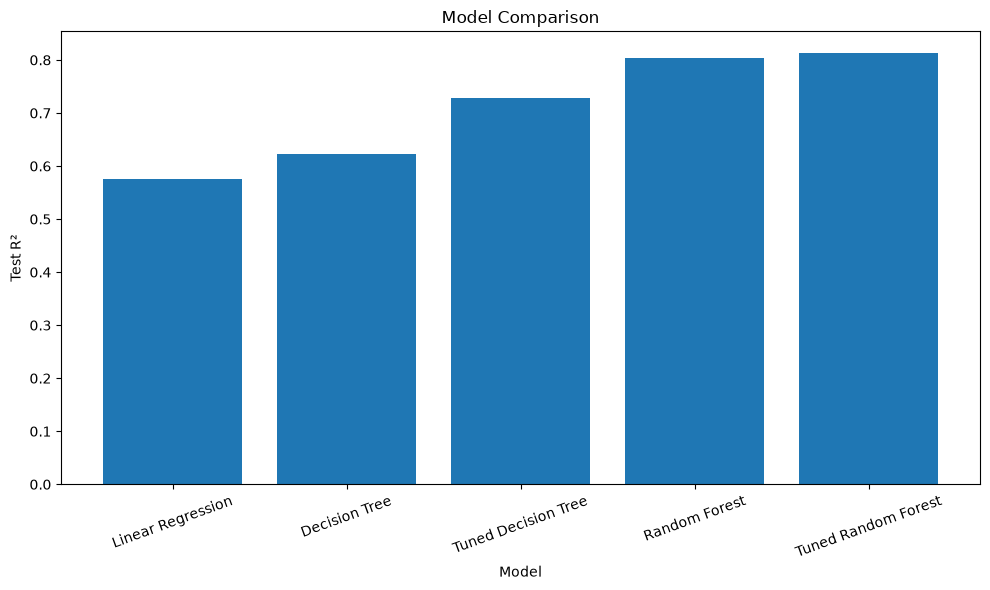

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    comparison["Model"],
    comparison["Test R²"]
)

plt.ylabel("Test R²")
plt.xlabel("Model")
plt.title("Model Comparison")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Model Comparison

We can now compare the models developed throughout the project.

Linear Regression provided our initial baseline with a test R² of approximately 0.576.

A basic Decision Tree improved the test R² to approximately 0.623. After controlling the tree's complexity using hyperparameters and cross-validation, the tuned Decision Tree achieved approximately 0.728.

The Random Forest produced a larger improvement. Our initial Random Forest achieved a test R² of approximately 0.805.

Finally, we used GridSearchCV to tune the Random Forest. The tuned model achieved a test R² of approximately 0.813, with an MAE of approximately 0.328 and an RMSE of approximately 0.495.

The progression demonstrates why we did not stop after building the initial linear regression model. The housing data contains nonlinear relationships that a simple linear model cannot capture as effectively. Decision trees and ensemble methods provide more flexible ways of modelling these relationships.

The Random Forest was the strongest model among those tested in this project based on the held-out test-set results.